## Getting Started

In [1]:
from COMPOSITION import *

/home/jeongbinpark/miniconda3/envs/minibatch/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jeongbinpark/miniconda3/envs/minibatch/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/jeongbinpark/miniconda3/envs/minibatch/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warning

In [2]:
# Source: https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-mouse-brain-fresh-frozen
adata = sc.read_h5ad('Visium_HD_Mouse_Brain_Fresh_Frozen_2um_Annotated.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 7238362 × 19059
    obs: 'in_tissue', 'array_row', 'array_col', 'annot_cluster', 'annot_cluster_nn', 'cleaned_cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'annot_cluster_colors', 'cleaned_cluster_colors', 'spatial'
    obsm: 'spatial'


/home/jeongbinpark/miniconda3/envs/minibatch/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Running

In [ ]:
%%time
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, zero_center=False, max_value=10)
sc.tl.pca(adata, n_comps=20)

# CPU times: user 13min 57s, sys: 6.49 s, total: 14min 4s
# Wall time: 1min 55s

In [ ]:
X = adata.obsm['X_pca']

adata.obs['x'] = adata.obs['array_row']
adata.obs['y'] = adata.obs['array_col']
sq.gr.spatial_neighbors(adata, coord_type='generic', delaunay=True, n_neighs=4, spatial_key='spatial')
cc.gr.remove_long_links(adata)
adjacency = adata.obsp['spatial_connectivities']

adata.write_h5ad("preprocessed_adata.h5ad")

In [2]:
adata = sc.read_h5ad("preprocessed_adata.h5ad")

/home/jeongbinpark/miniconda3/envs/minibatch/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
X = adata.obsm['X_pca']
adjacency = adata.obsp['spatial_connectivities']

In [4]:
def load_data(X, adjacency):
    """
    Converts the node features and adjacency matrix into a PyTorch Geometric `Data` object.

    Args:
        X (np.ndarray): Node features, shape (num_nodes, num_features).[real number]
        adjacency (scipy.sparse.csr_matrix): Adjacency matrix of the graph.[{0,1}]

    Returns:
        Data: PyTorch Geometric `Data` object containing:
              - x (torch.Tensor): Node features, shape (num_nodes, num_features).
              - edge_index (torch.Tensor): Edge indices in COO format, shape (2, num_edges).
    """
    
    # Ensure adjacency is in COO format
    adjacency_coo = adjacency.tocoo()
    edge_index = np.vstack((adjacency_coo.row, adjacency_coo.col))
    edge_index = torch.tensor(edge_index, dtype=torch.long)

    # Convert the DataFrame to a NumPy array and then to a PyTorch tensor
    x = torch.tensor(X, dtype=torch.float)

    return Data(x=x, edge_index=edge_index)

In [13]:
data=load_data(X, adjacency)
hid_dim=128
dim=48
n_celltypes=20

In [6]:
dataloader = NeighborLoader( 
    data,
    input_nodes=torch.arange(data.num_nodes), # [0, 1, 2, ..., n_obs-1]
    num_neighbors=[10,5],                     # Node sampling for each GNN layer
    batch_size=2048,                          # Number of center nodes for each batch
    shuffle=True
)

/home/jeongbinpark/miniconda3/envs/minibatch/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


In [ ]:
%%time
model, model_ct, model_ff = step2_run(data, dataloader, num_topics=16, epochs=600, lr=9e-4, minibatch=True, seed=1, lr=9e-4)

# ~1 hr / 10 epochs

In [15]:
'''
model = VGAE(ProdLDAEncoder(data.num_features, hid_dim, dim))
model.load_state_dict(torch.load("COMPOSITION_visiumhd_2um/model.pth"))

model_ff = FFPredict(dim, n_celltypes)
model_ff.load_state_dict(torch.load("COMPOSITION_visiumhd_2um/model_ff.pth"))

model_ct = VAE(data.num_features, hid_dim, 1, num_categories=n_celltypes)
model_ct.load_state_dict(torch.load("COMPOSITION_visiumhd_2um/model_ct.pth"))
'''

<All keys matched successfully>

## Visiualization

/tmp/ipykernel_2484433/109067806.py:26: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  recon = F.softmax(model_ff(p))             # reconstructed distribution over vocabulary


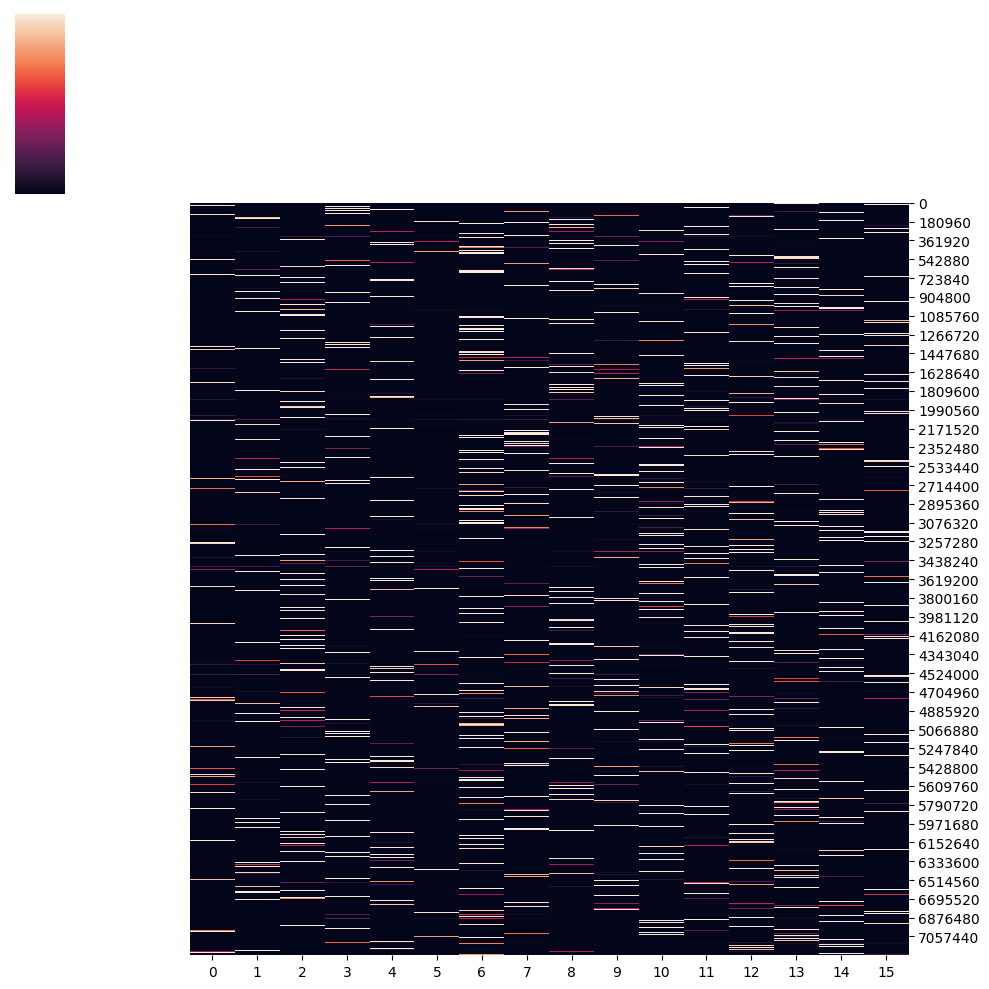

In [16]:
device = torch.device('cpu')
model = model.to(device)
model_ff = model_ff.to(device)
model_ct = model_ct.to(device)
data.x = data.x.to(device)
data.edge_index = data.edge_index.to(device)

model.eval()
with torch.no_grad():
    n_samples = 1
    p_mat = []
    with torch.no_grad():
        for r in range(n_samples):
            z, p, posterior_mean, posterior_logvar, posterior_var = model.encoder(data.x, data.edge_index)
            p_mat.append(p)

    p = torch.stack(p_mat, dim=0).mean(dim=0)
    #z, p, posterior_mean, posterior_logvar, posterior_var = model.encoder(data.x, data.edge_index)
    recon = F.softmax(model_ff(p))             # reconstructed distribution over vocabulary

seaborn.clustermap( p.detach().cpu().numpy(), row_cluster=False, col_cluster=False)
plt.axis(False)
plt.show()

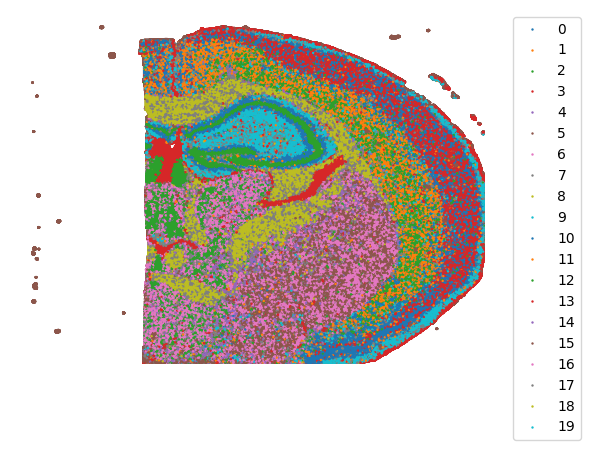

In [17]:
pred_labels = KMeans(n_clusters=20, random_state=0).fit_predict(p.detach().cpu())

seaborn.scatterplot(x=adata.obs.x, y=adata.obs.y, hue=pred_labels, palette='tab10', s=3, linewidth=0)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.axis('off')
plt.show()